# Pizza Pepperoni Classification
### A simplified AI-based pizza checker, built using deep learning in Python

Whether the correct pizza has been made — either a pepperoni pizza or a plain cheese pizza — is checked in this project. An AI model is trained using a dataset of pre-classified images of pepperoni pizzas and plain cheese pizzas. A Convolutional Neural Network (CNN) model is created, trained, and evaluated with Keras and TensorFlow for a binary image classification task.

#### Load the dependencies
The functions and classes needed to build the model are defined first. Several libraries are imported for data manipulation, model creation, training, and evaluation:

* keras — used for building the neural network
* sklearn.metrics — used for evaluation metrics
* tensorflow — used for backend operations
* cv2 (OpenCV) — used for image processing
* os — used for file system operations
* numpy — used for numerical operations
* matplotlib.pyplot and seaborn — used for plotting
* shutil — used to unpack archives


In [1]:
# Load the libraries needed
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D , MaxPool2D , Flatten , Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report,confusion_matrix
import tensorflow as tf
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shutil

#### Unzipping training and testing data

Once the zip files are uploaded, they are unzipped using the following code. These zipped files contain the image data for training and testing the model, organised into folders named after the classes (Cheese and Pepperoni).


In [2]:
# Unzip Training.zip and Testing.zip
shutil.unpack_archive("Training.zip", "/content/")
shutil.unpack_archive("Testing.zip", "/content/")

#### Data preparation

The labels used in this model are defined — 'Cheese' and 'Pepperoni' — along with the image size used throughout (100 pixels by 100 pixels).


In [3]:
# Define labels and image size
labels = ['Cheese', 'Pepperoni']
img_size = 100

A function is also defined to read and pre-process the image files. This function loads images from a specified directory (`data_dir`), converts them from BGR to RGB (since OpenCV loads images in BGR format), resizes them to 100x100 pixels, and appends them to a list along with their class labels. The data is then returned as a NumPy array.


In [4]:
# Define the get_data function that loads the images
def get_data(data_dir):
    data = []
    for label in labels:
        path = os.path.join(data_dir, label)
        class_num = labels.index(label)
        for img in os.listdir(path):
            try:
                img_arr = cv2.imread(os.path.join(path, img))
                if img_arr is None:
                    continue  # Skip files that aren't valid images
                img_arr = cv2.cvtColor(img_arr, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB format
                resized_arr = cv2.resize(img_arr, (img_size, img_size))  # Reshaping images to preferred size
                data.append([resized_arr, class_num])
            except Exception as e:
                print(f"Error processing image {img}: {e}")
    # Convert data to a NumPy array for the image features, and a list for the labels
    X = np.array([item[0] for item in data], dtype=object)
    y = np.array([item[1] for item in data])
    return X, y

#### Loading and preparing data

The training and testing data is loaded next by calling the `get_data` function defined earlier, then prepared for the training process. The datasets are split into features (`x_train`, `x_test`) and labels (`y_train`, `y_test`), and the feature data is normalised by dividing by 255 (to bring pixel values into the range [0,1]). The labels are also converted to NumPy arrays.


In [5]:
# Load the training images
X_train, y_train = get_data('/content/Training')
# Load the testing images
X_test, y_test = get_data('/content/Testing')

# Normalise the data
X_train = np.array(X_train, dtype=np.float32) / 255
X_test = np.array(X_test, dtype=np.float32) / 255

# The reshaping of X_train and X_test to ensure they have the correct shape should be handled directly (assuming they are already in a 4D array format needed for CNNs):
X_train = X_train.reshape(-1, img_size, img_size, 3)
X_test = X_test.reshape(-1, img_size, img_size, 3)

# Ensure y_train and y_test are numpy arrays (they should already be, but this is just to be safe)
y_train = np.array(y_train, dtype=np.int32)
y_test = np.array(y_test, dtype=np.int32)

#### Model Creation
A sequential CNN model is created with:

* Three convolutional layers, each followed by a max-pooling layer. The input shape (100x100 pixels with 3 color channels, RGB) is specified by the first layer.
* A dropout layer, included to reduce overfitting.
* A flatten layer, used to convert the 2D feature maps into a 1D vector.
* Two dense (fully connected) layers, the final one using a softmax activation function for binary classification.


In [6]:
# Initialise a Convolutional Neural Network (CNN) model
model = Sequential()
model.add(Conv2D(32,3,padding="same", activation="relu", input_shape=(img_size,img_size,3)))
model.add(MaxPool2D())

model.add(Conv2D(32, 3, padding="same", activation="relu"))
model.add(MaxPool2D())

model.add(Conv2D(64, 3, padding="same", activation="relu"))
model.add(MaxPool2D())
model.add(Dropout(0.4))

model.add(Flatten())
model.add(Dense(128,activation="relu"))
model.add(Dense(2, activation="softmax"))

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,208,674 (4.61 MB)

 Trainable params: 1,208,674 (4.61 MB)

 Non-trainable params: 0 (0.00 B)

#### Model Compilation

The model is compiled with the Adam optimiser and the sparse categorical crossentropy loss function. This setup is typical for multi-class classification tasks, even though this is a binary classification, represented as a 2-class problem.

In [7]:
# Compile the model
opt = Adam()
model.compile(optimizer = opt , loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True) , metrics = ['accuracy'])

### Model Training

The model is trained on the training data with validation on the testing data for 10 epochs. Training history is plotted to visualise the accuracy over epochs for both training and validation data.

Epoch 1/10


/usr/local/lib/python3.13/dist-packages/keras/src/backend/tensorflow/nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 476ms/step - accuracy: 0.5833 - loss: 0.6881 - val_accuracy: 0.7800 - val_loss: 0.5930
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 554ms/step - accuracy: 0.7233 - loss: 0.5365 - val_accuracy: 0.7850 - val_loss: 0.4311
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 547ms/step - accuracy: 0.8300 - loss: 0.4044 - val_accuracy: 0.8800 - val_loss: 0.3199
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 463ms/step - accuracy: 0.8617 - loss: 0.3193 - val_accuracy: 0.9150 - val_loss: 0.1921
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 476ms/step - accuracy: 0.8767 - loss: 0.2824 - val_accuracy: 0.9500 - val_loss: 0.1566
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 545ms/step - accuracy: 0.9050 - loss: 0.2349 - val_accuracy: 0.9500 - val_loss: 0.1609
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 514ms/step - accuracy: 0.8983 - loss: 0.2516 - val_accuracy: 0.9100 - val_loss: 0.2092
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 440ms/step - accuracy: 0.9400 - loss: 0.1797 - val_accuracy: 0.9450 

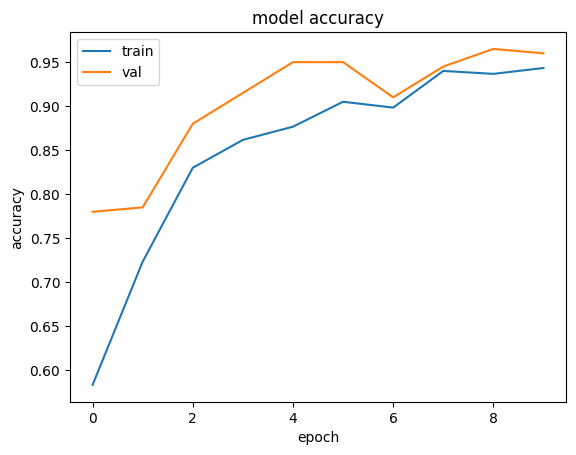

In [8]:
# Fit the model to the data
history = model.fit(X_train,y_train,epochs = 10 , validation_data = (X_test, y_test))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

#### Model Evaluation

Finally, the model's performance is evaluated on the test set. Predictions are made using the `model.predict` method, and the results are analysed using a confusion matrix and a classification report, in which precision, recall, and F1-score are provided for each class.


In [9]:
# Classify images (predict) using the Convolutional Neural Network (CNN) model
predictions = model.predict(X_test)
predictions = np.argmax(predictions, axis=1)
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions, target_names = ['Cheese (Class 0)','Pepperoni (Class 1)']))

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step
[[94  6]
 [ 2 98]]
                     precision    recall  f1-score   support

   Cheese (Class 0)       0.98      0.94      0.96       100
Pepperoni (Class 1)       0.94      0.98      0.96       100

           accuracy                           0.96       200
          macro avg       0.96      0.96      0.96       200
       weighted avg       0.96      0.96      0.96       200



#### Interpreting the results

Strong performance is shown by the model on the held-out test set:

**Accuracy: 96%** — 192 of the 200 test images are correctly classified.

**Confusion Matrix:**
 [[94 6]
[ 2 98]]



Of the 100 cheese pizzas in the test set, 94 are correctly identified and 6 are mistaken for pepperoni. Of the 100 pepperoni pizzas, 98 are correctly identified and only 2 are mistaken for cheese.

**Precision, Recall, and F1 Score** are balanced and high across both classes:
* Cheese: precision 0.98, recall 0.94, F1 0.96
* Pepperoni: precision 0.94, recall 0.98, F1 0.96

Slightly more false positives are produced for cheese being misclassified as pepperoni (6) than the reverse (2), but performance is strong and consistent in both directions — no meaningful bias toward one class is shown by the model.

This result stands in contrast to the earlier tabular-data projects (Total Spend, Churn), where linear and ensemble models struggled to beat a naive baseline. Here, a clear, learnable visual signal is present in the images — pepperoni and cheese pizzas look different enough that a CNN can reliably tell them apart, unlike the tabular datasets where the underlying features carried little real relationship with the target.

**A technical note:** a warning is raised during training — `sparse_categorical_crossentropy received from_logits=True, but the output was produced by a Softmax activation`. This happens because the final layer already applies a softmax activation (producing class probabilities), while the loss function is configured with `from_logits=True` (which expects raw, unnormalised scores rather than probabilities). Training and evaluation still complete successfully here, but this is a minor inconsistency worth fixing — either by setting `from_logits=False` (the default) or by removing the softmax activation from the final layer.